In [1]:
# load data
from google.colab import drive
drive.mount('/content/drive')



import numpy as np
from matplotlib import pyplot as plt
import scipy.io

folder_path = "/content/drive/MyDrive/CNN_pred/"

NumImages=10000   # number of data to be used
NumTotalImages= 10000  # number of data available
icomp = 0
nParams = 1
dir = folder_path + "InputData/" + "10000_Fiber_centers_L_50_radius2.5_res_128" + ".mat" # note that circle centers are in pixels, and r = 6.4 is the radius
mat = scipy.io.loadmat(dir)
x_data=mat['centers_all']
########################################### target data #######################################################

filename = folder_path + 'InputData/'+ str(NumTotalImages) + '_Params_Stiffness_ratio_100'  + '_Lw_50.txt'
Y = np.loadtxt(filename,dtype="float",max_rows=int(NumImages))

y_data = np.zeros((NumImages,nParams))
if nParams ==1:
    y_data = Y[:,icomp]
elif nParams == 4:
    y_data[:,0] = Y[:,0]
    y_data[:,1] = Y[:,1]
    y_data[:,2] = Y[:,3]
    y_data[:,3] = Y[:,5]
    string_list=['C11','C12','C22','C33']
elif nParams ==6:
    y_data = Y

minlist = np.min(y_data, axis=0) if nParams > 1 else np.min(y_data)
maxlist = np.max(y_data, axis=0) if nParams > 1 else np.max(y_data)
y_data = (y_data - minlist) / (maxlist - minlist)

filename = folder_path + 'InputData/'+ str(NumTotalImages) + '_VF_Stiffness_ratio_100'  + '_Lw_50.txt'
actual_vf = np.loadtxt(filename,dtype="float",usecols =(0),max_rows=int(NumImages))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install torch-geometric # Install torch_geometric for colab

In [3]:
import torch
from torch_geometric.data import Data # need !pip install torch-geometric on collab

graphs = []
k = 6 # nearest neighbors

for igraph in range(NumImages):
  node_features = x_data[igraph][0] # the node features (n,2)

  if node_features.shape[0] < k+1: # If there are <k+1 nodes, skip graph (should be adjusted later)
      continue

  x = node_features[:,0]
  y = node_features[:,1]
  n = len(x)
  #Lmin = -12.8 # if normalization is needed
  #Lmax = 140.8
  #x = (x - Lmin) / Lmax
  #y = (y - Lmin) / Lmax
  ################################################################# nearest neibhors
  dist = np.sqrt((x[:,None] - x[None,:])**2 +  (y[:,None] - y[None,:])**2)

  idx = np.argpartition(dist, k, axis=0)[:k+1, :]
  vals = np.take_along_axis(dist, idx, axis=0)

  # Remove the zero distances
  idx = idx[1:]
  vals = vals[1:]
  ######################################################################

  # the edge features
  edge_features = np.zeros((k*n,3))
  edge_ids = np.zeros((2,k*n))

  for inode in range(n):
      for j in range(k):
          edge_features[inode*k + j,:] = [x[inode]-x[idx[j,inode]],y[inode]-y[idx[j,inode]],vals[j,inode]] #
          edge_ids[:,inode*k + j] = [inode, idx[j,inode]]
#Note: this graph is directional, might not be optimal

####################### build graph #####################################
  x = torch.from_numpy(node_features).float()
  edge_attr = torch.from_numpy(edge_features).float()
  edge_index = torch.from_numpy(edge_ids).long()

  graphs.append(Data(
            x=x,                  # (n, 2)
            edge_index=edge_index, # (2, k*n)
            edge_attr=edge_attr,   # (k*n, 3)
            y=torch.tensor([y_data[igraph]]).float(),
            parameter=torch.tensor([actual_vf[igraph]]).float() # vf parameter, only for final plot
        )
    )

print("done")

done


In [4]:
# network structure, train/test set

from torch_geometric.loader import DataLoader
from torch.utils.data import random_split
import torch.nn as nn
from torch_geometric.nn import GINEConv, global_mean_pool


n = len(graphs)
n_train = int(0.70 * n)
n_val = int(0.15 * n)
n_test = n - n_train - n_val

train_graphs, val_graphs, test_graphs = random_split(
    graphs,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=32, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=32, shuffle=False)

class GNN(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()

        self.conv1 = GINEConv(
            nn.Sequential(
                nn.Linear(2, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            ), edge_dim=3
        )

        self.conv2 = GINEConv(
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            ), edge_dim=3
        )
        self.conv3 = GINEConv(
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            ), edge_dim=3
        )
        self.predictor = nn.Sequential(
                nn.Linear(128, 128), # 3 layer nn
                nn.ReLU(),
                nn.Linear(128, 64),
                nn.ReLU(),
                nn.Linear(64, 1)

                #nn.Linear(hidden_dim, 64), # 2 layer nn
                #nn.ReLU(),
                #nn.Linear(64, 1)

        )

    def forward(self, x, edge_index, edge_attr, batch):
        x = torch.relu(self.conv1(x, edge_index, edge_attr)) # without residual connections
        x = torch.relu(self.conv2(x, edge_index, edge_attr))
        x = torch.relu(self.conv3(x, edge_index, edge_attr))

        #x = torch.relu(self.conv1(x, edge_index, edge_attr))
        #h = self.conv2(x, edge_index, edge_attr) # testing residual connections
        #x = torch.relu(x + h)
        #h = self.conv3(x, edge_index, edge_attr)
        #x = torch.relu(x + h)

        x = global_mean_pool(x, batch)
        return self.predictor(x)

Using: cuda
Epoch 000 | Train: 1.9184 | Val: 0.0282
Epoch 001 | Train: 0.0175 | Val: 0.0456
Epoch 002 | Train: 0.0157 | Val: 0.0288
Epoch 003 | Train: 0.0130 | Val: 0.0063
Epoch 004 | Train: 0.0100 | Val: 0.0234
Epoch 005 | Train: 0.0079 | Val: 0.0070
Epoch 006 | Train: 0.0072 | Val: 0.0057
Epoch 007 | Train: 0.0061 | Val: 0.0047
Epoch 008 | Train: 0.0056 | Val: 0.0085
Epoch 009 | Train: 0.0071 | Val: 0.0045
Epoch 010 | Train: 0.0053 | Val: 0.0043
Epoch 011 | Train: 0.0056 | Val: 0.0075
Epoch 012 | Train: 0.0062 | Val: 0.0045
Epoch 013 | Train: 0.0047 | Val: 0.0043
Epoch 014 | Train: 0.0049 | Val: 0.0059
Epoch 015 | Train: 0.0047 | Val: 0.0041
Epoch 016 | Train: 0.0048 | Val: 0.0062
Epoch 017 | Train: 0.0047 | Val: 0.0061
Epoch 018 | Train: 0.0043 | Val: 0.0045
Epoch 019 | Train: 0.0043 | Val: 0.0044
Epoch 020 | Train: 0.0041 | Val: 0.0052
Epoch 021 | Train: 0.0044 | Val: 0.0052
Epoch 022 | Train: 0.0042 | Val: 0.0048
Epoch 023 | Train: 0.0042 | Val: 0.0037
Epoch 024 | Train: 0.0041 | 

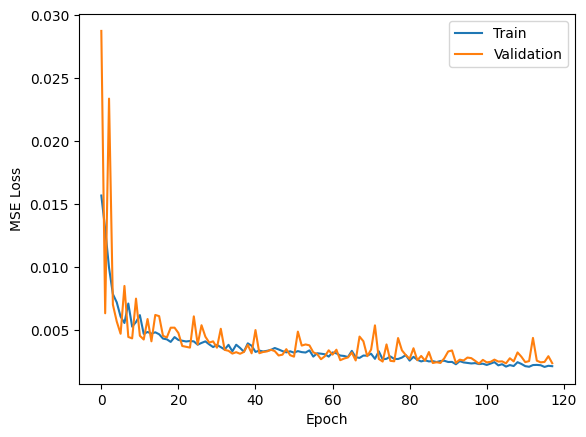

In [5]:
# Training
train_losses, val_losses = [], []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

model = GNN(hidden_dim=128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

for epoch in range(120):
    model.train()
    train_loss = 0

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        pred = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss = criterion(pred.squeeze(-1), batch.y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            pred = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            val_loss += criterion(pred.squeeze(-1), batch.y).item()

    print(f"Epoch {epoch:03d} | Train: {train_loss/len(train_loader):.4f} | Val: {val_loss/len(val_loader):.4f}")

    train_losses.append(train_loss / len(train_loader))
    val_losses.append(val_loss / len(val_loader))

plt.plot(train_losses[2:], label="Train")
plt.plot(val_losses[2:], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

MAPE: 5.16%
6260training samples
MSE: 0.0024 | RMSE: 0.0485 | MAE: 0.0374 | R²: 0.9439


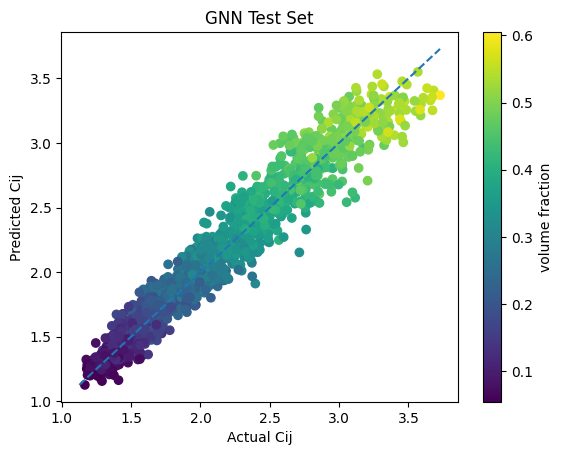

In [6]:
# predictions
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model.eval()
predictions, actual, parameters = [], [], []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        pred = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        predictions.extend(pred.squeeze(-1).cpu().numpy())
        actual.extend(batch.y.cpu().numpy())
        parameters.extend(batch.parameter.squeeze(-1).cpu().numpy())

predictions, actual, parameters = map(np.array, (predictions, actual, parameters))

mse = mean_squared_error(actual, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual, predictions)
r2 = r2_score(actual, predictions)
actual = actual * (maxlist - minlist) + minlist
predictions = predictions * (maxlist - minlist) + minlist
mape = np.mean(np.abs((actual - predictions) / actual)) * 100
print(f"MAPE: {mape:.2f}%")
print(str(n_train) + "training samples")
print(f"MSE: {mse:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")

plt.scatter(actual, predictions, c=parameters, cmap="viridis")
plt.xlabel("Actual Cij")
plt.ylabel("Predicted Cij")
plt.title("GNN Test Set")
plt.colorbar(label="volume fraction")

lims = [min(actual.min(), predictions.min()), max(actual.max(), predictions.max())]
plt.plot(lims, lims, "--")
plt.show()
